## p78

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
"""
Build a 7x124 control signal array for a robot arm animation.
Axis convention:
  0 = waist (base yaw)
  1 = shoulder pitch
  2 = upper arm roll
  3 = elbow
  4 = forearm roll
  5 = wrist
  6 = gripper (0=open, 1=closed)
"""
import numpy as np
from scipy.ndimage import gaussian_filter1d
import matplotlib.pyplot as plt

N_FRAMES = 124
N_AXES = 7


def smoothstep(t):
    """Cubic ease in/out on [0,1]."""
    t = np.clip(t, 0.0, 1.0)
    return t * t * (3.0 - 2.0 * t)


def interp_keyframes(keyframes, n_frames):
    """Smooth-step interpolate between sorted (frame, value) keyframes."""
    kf = sorted(keyframes)
    arr = np.zeros(n_frames)
    # hold-before
    f0, v0 = kf[0]
    arr[: f0 + 1] = v0
    # interpolate between successive keyframes
    for (f0, v0), (f1, v1) in zip(kf[:-1], kf[1:]):
        if f1 == f0:
            arr[f0] = v1
            continue
        for f in range(f0, f1 + 1):
            t = (f - f0) / (f1 - f0)
            arr[f] = v0 + (v1 - v0) * smoothstep(t)
    # hold-after
    fL, vL = kf[-1]
    arr[fL:] = vL
    return arr


# ----- Keyframes per joint -----
# Frames: 0-6 down toward cup; 10-16 grip; 18-25 pull-in; 30-37 twist off
# platform; 37-44 halfway down; 49-60 rest of the way down; 60-100 hold w/
# small motions; 100-108 release; 108-115 retreat up; 115-123 still.

waist = [
    (0,   0.00),
    (6,   0.04),   # tiny lateral align while reaching
    (16,  0.04),
    (25,  0.02),   # pulled in, slight unwind
    (30,  0.02),
    (37,  0.45),   # twist off the platform
    (44,  0.55),
    (60,  0.62),
    (100, 0.62),
    (108, 0.62),
    (115, 0.00),   # return to neutral
    (123, 0.00),
]

shoulder = [
    (0,   0.00),
    (6,  0.35),   # tilt down to cup
    (10, 0.35),
    (16, 0.35),
    (18, 0.35),
    (25, 0.28),   # ease back as cup pulls in
    (30, 0.28),
    (37, 0.22),   # rise a bit to clear platform
    (44, 0.40),   # back down halfway
    (60, 0.55),   # most of the way down
    (100, 0.55),
    (108, 0.55),
    (115,  0.00),  # retreat up
    (123,  0.00),
]

upper_roll = [
    (0,   0.00),
    (16,  0.00),
    (30,  0.00),
    (37,  0.08),   # small roll during twist
    (60,  0.12),
    (100, 0.12),
    (108, 0.12),
    (115, 0.00),
    (123, 0.00),
]

elbow = [
    (0,   0.00),
    (6,   0.65),   # bend to reach down
    (10,  0.65),
    (16,  0.65),
    (18,  0.65),
    (25,  0.48),   # pull cup toward body
    (30,  0.48),
    (37,  0.42),   # lift to clear platform
    (44,  0.70),   # halfway down
    (60,  0.92),   # most of way down
    (100, 0.92),
    (108, 0.92),
    (115, 0.00),
    (123, 0.00),
]

forearm_roll = [
    (0,   0.00),
    (6,   0.05),
    (16,  0.05),
    (30,  0.05),
    (37,  0.18),   # roll a touch with the twist
    (60,  0.22),
    (100, 0.22),
    (108, 0.22),
    (115, 0.00),
    (123, 0.00),
]

wrist = [
    (0,   0.00),
    (6,   0.12),   # tip wrist to align with cup
    (16,  0.10),
    (30,  0.08),
    (37,  0.05),
    (60,  0.00),
    (100, 0.00),
    (108, 0.00),
    (115, 0.00),
    (123, 0.00),
]

# Gripper: 0 = open, 1 = closed
gripper = [
    (0,   0.0),
    (10,  0.0),
    (16,  1.0),    # close on cup
    (100, 1.0),
    (108, 0.0),    # release
    (123, 0.0),
]

all_kfs = [waist, shoulder, upper_roll, elbow, forearm_roll, wrist, gripper]
control = np.zeros((N_AXES, N_FRAMES), dtype=np.float64)
for i, kf in enumerate(all_kfs):
    control[i] = interp_keyframes(kf, N_FRAMES)

# Small idle motion in frames 60-100 (the "little motions towards the table
# and around"). Smooth low-amplitude noise on joints, none on gripper.
rng = np.random.default_rng(7)
idle_lo, idle_hi = 60, 100
idle_len = idle_hi - idle_lo
amps = [0.015, 0.012, 0.010, 0.018, 0.010, 0.015]  # per joint
for i in range(6):
    n = rng.standard_normal(idle_len)
    n = gaussian_filter1d(n, sigma=3.0)
    n = n / (np.max(np.abs(n)) + 1e-9) * amps[i]
    # taper at endpoints so we don't kink the surrounding hold
    taper = np.minimum(np.arange(idle_len), idle_len - 1 - np.arange(idle_len))
    taper = np.clip(taper / 6.0, 0.0, 1.0)
    control[i, idle_lo:idle_hi] += n * taper

# ----- Save -----
# np.save('/mnt/user-data/outputs/robot_control.npy', control)

# # ----- Visualize -----
# labels = ['waist', 'shoulder', 'upper_roll', 'elbow',
#           'forearm_roll', 'wrist', 'gripper']
# fig, axes = plt.subplots(7, 1, figsize=(11, 10), sharex=True)
# events = [
#     (0, 6, 'reach down'),
#     (10, 16, 'grip'),
#     (18, 25, 'pull in'),
#     (30, 37, 'twist off'),
#     (37, 44, 'half down'),
#     (49, 60, 'rest down'),
#     (60, 100, 'idle'),
#     (100, 108, 'release'),
#     (108, 115, 'retreat'),
#     (115, 123, 'hold'),
# ]
# for ax, sig, lab in zip(axes, control, labels):
#     for s, e, _ in events:
#         ax.axvspan(s, e, alpha=0.05, color='C1')
#     ax.plot(sig, lw=1.6)
#     ax.set_ylabel(lab, fontsize=9)
#     ax.grid(alpha=0.25)
# axes[-1].set_xlabel('frame')
# axes[0].set_title('Robot arm control signals (7 x 124)')
# plt.tight_layout()
# plt.savefig('/mnt/user-data/outputs/robot_control_preview.png', dpi=120)

# print('shape:', control.shape, 'dtype:', control.dtype)
# print('per-axis (min, max):')
# for lab, sig in zip(labels, control):
#     print(f'  {lab:14s}  ({sig.min():+.3f}, {sig.max():+.3f})')

In [3]:
control.shape

(7, 124)

In [4]:
control_2=control*np.array([[-1, 0.8, -1, -1.0, 0.8, -1, 0.7]]).T

(-6.15, 129.15, -1.0045900943611996, 0.7811709568743428)

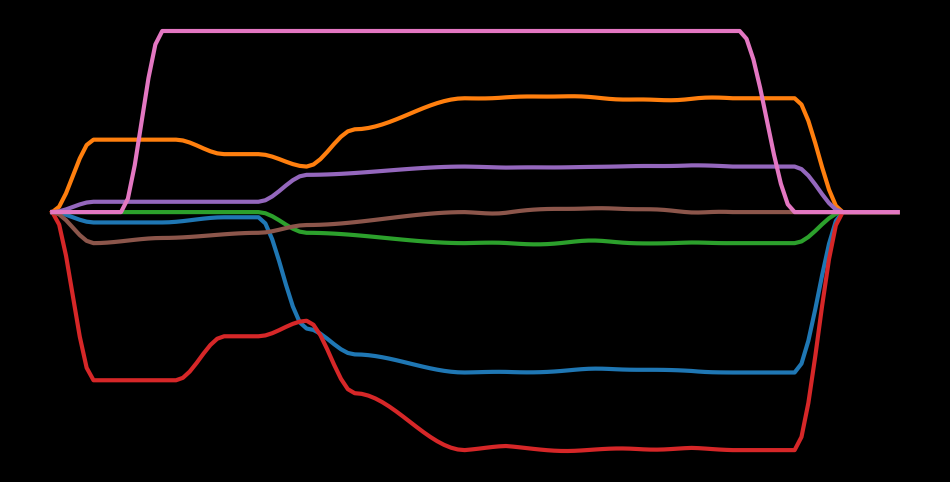

In [5]:
fig=plt.figure(0, (12, 6),facecolor='k')
ax=fig.add_subplot(111, facecolor='k')

plt.plot(control_2.T, linewidth=3);
plt.axis('off')

In [6]:
save_dir='/Users/stephen/Stephencwelch Dropbox/welch_labs/jepa/graphics/p78_control_sigs'

<Figure size 640x480 with 0 Axes>

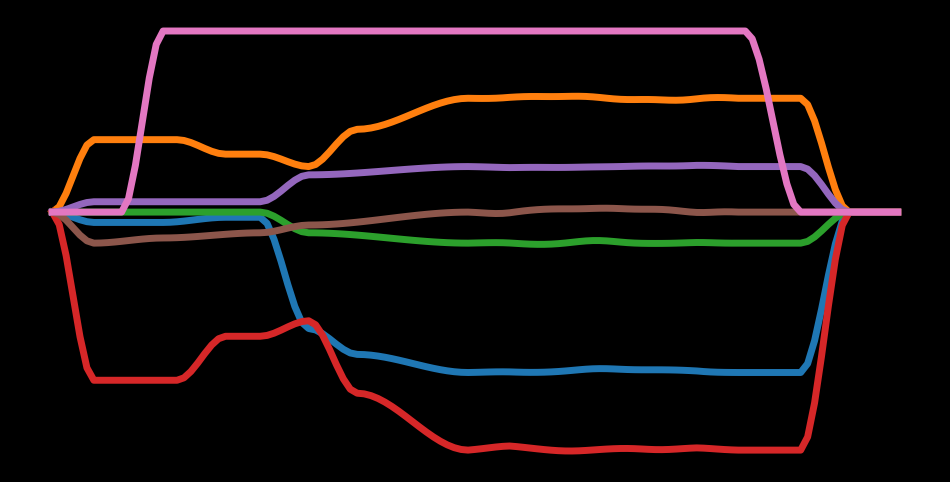

In [41]:
for i in range(control_2.shape[1]):
    plt.clf()
    fig=plt.figure(0, (12, 6),facecolor='k')
    ax=fig.add_subplot(111, facecolor='k')
    
    plt.plot(control_2[:, :i].T, linewidth=5);
    plt.axis('off')
    plt.savefig(save_dir+'/'+str(i).zfill(3)+'.png', transparent=True)

In [7]:
save_dir='/Users/stephen/Stephencwelch Dropbox/welch_labs/jepa/graphics/p79_control_sigs'

<Figure size 640x480 with 0 Axes>

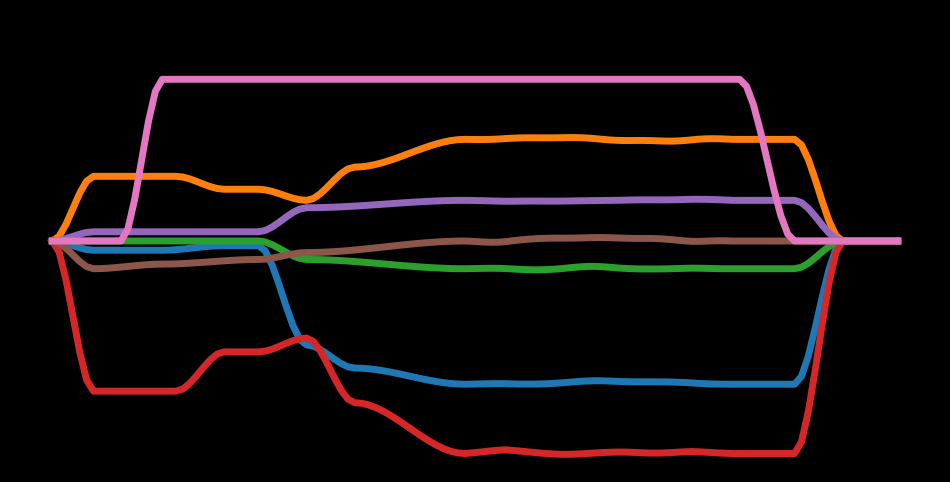

In [13]:
num_steps=128

for i in range(num_steps):
    plt.clf()
    fig=plt.figure(0, (12, 6),facecolor='k')
    ax=fig.add_subplot(111, facecolor='k')

    # printi/(num_steps-1)
    plt.plot((i/(num_steps-1))*control_2.T, linewidth=5);
    plt.axis('off')
    plt.ylim([-1, 1])
    plt.savefig(save_dir+'/'+str(i).zfill(3)+'.png', transparent=True)
   

In [9]:
control_2.shape

(7, 124)

In [10]:
# np.zeros_like(control_2)+(i/(num_steps-1))*control_2

NameError: name 'num_steps' is not defined